# 8주차 실습 (1) — Complex Numbers for AI

> **−1의 제곱근은 상상 속 숫자가 아닙니다. 회전과 주파수, 그리고 신호처리 절반의 열쇠입니다.**

- **Type:** Learn · **Language:** Python · **Time:** ~60분
- **선수 지식:** Phase 1 Lesson 01~04 (선형대수, 미적분)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/19-complex-numbers>

## 🎯 학습 목표

1. 직교형·극형 양쪽에서 **복소수 사칙연산과 켤레**를 수행합니다.
2. **오일러 공식**으로 복소지수와 삼각함수를 오갑니다.
3. **1의 거듭제곱근**을 이용해 **이산 푸리에 변환(DFT)** 을 구현합니다.
4. 복소 회전이 트랜스포머의 **RoPE**와 **사인 위치 인코딩**의 밑바탕임을 설명합니다.

---

## 📖 이 노트북을 읽는 법

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 논문마다 나오는 `i`의 정체 |
| 1 | 복소수란 무엇인가 · 사칙연산 |
| 2 | 복소평면 — 수를 평면 위의 점으로 |
| 3 | 극형 — 곱셈이 갑자기 쉬워집니다 |
| 4 | 🔑 오일러 공식 — 이 레슨의 심장 |
| 5 | `i`는 사실 90° 회전 연산자입니다 |
| 6 | 복소수 곱셈 = 2D 회전 행렬 (완전히 같습니다) |
| 7 | 페이저 — 사인파는 회전하는 화살표의 그림자 |
| 8 | 1의 거듭제곱근 |
| 9 | 🔨 DFT와 IDFT를 복소 산술만으로 구현 |
| 10 | 🏭 트랜스포머 — 사인 위치 인코딩과 RoPE |
| 11 | 📝 연습문제 5개 (풀이 포함) |
| 12 | 📚 용어 사전 · 더 읽을거리 |

## 0️⃣ 문제 상황 — 논문마다 나오는 `i`의 정체

푸리에 변환 논문을 열면 `i`가 사방에 있습니다.
트랜스포머 위치 인코딩을 보면 서로 다른 주파수의 `sin`과 `cos`이 나오는데,
사실 그건 **복소지수의 실수부와 허수부**입니다.
양자컴퓨팅 자료를 보면 모든 게 복소 벡터공간으로 표현되어 있고요.

복소수는 추상적으로 느껴집니다. **"−1의 제곱근"** 위에 세운 수 체계라니, 수학적 속임수 같죠.

**하지만 속임수가 아닙니다. 복소수는 회전과 진동의 자연스러운 언어입니다.**
무언가가 **돌거나, 떨거나, 진동할 때마다** 복소수가 올바른 도구입니다.

복소수를 모르면 이런 것들을 이해할 수 없습니다.

- **DFT와 FFT** — 다음 노트북의 주제입니다
- **RoPE** (Rotary Position Embedding) — 요즘 언어모델이 거의 다 씁니다
- 원조 트랜스포머 논문의 **사인 위치 인코딩**이 왜 하필 그 주파수들을 쓰는지

---

### 🧭 이번 노트북의 지도

이 레슨은 **하나의 아이디어**로 꿰어집니다.

```
        i를 곱한다 = 90° 회전한다   (5절)
                    │
                    ▼
        e^(iθ) = cos θ + i sin θ   (4절 오일러 공식)
        "복소지수 = 단위원 위의 회전"
                    │
        ┌───────────┴───────────┐
        ▼                       ▼
   회전 = 곱셈 하나 (6절)     회전 = 진동 (7절 페이저)
        │                       │
        ▼                       ▼
   RoPE (10절)            1의 거듭제곱근 (8절) → DFT (9절)
```

**"`i`를 곱하면 90° 돈다"** 이 한 줄만 붙잡으면 나머지는 전부 그 위에 쌓입니다.

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
import cmath

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=5, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 축 눈금의 유니코드 마이너스(U+2212)가 깨지지 않습니다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [2]:
# 30초 데모 — 'i를 곱하면 90도 돈다'를 먼저 눈으로 확인하고 시작합니다
z = 1 + 0j                      # 실수축 위의 점 (1, 0)
print("1에 i를 계속 곱해 봅니다\n")
print(f"{'횟수':>6}{'값':>20}{'각도':>12}{'크기':>10}")
print("-" * 50)
for k in range(5):
    ang = math.degrees(cmath.phase(z)) % 360
    print(f"{k:>6}{str(z):>20}{ang:>11.1f}°{abs(z):>10.4f}")
    z = z * 1j

print("\n=> 네 번 곱하면 제자리로 돌아옵니다. 90° × 4 = 360°이니까요.")
print("   그리고 두 번 곱하면 -1이 됩니다. 즉 i² = -1 은")
print("   '90도를 두 번 돌면 180도(반대 방향)' 라는 뜻입니다. 전혀 신비롭지 않습니다.")
print(f"\n   크기는 계속 1입니다 — 회전은 길이를 바꾸지 않습니다.")

1에 i를 계속 곱해 봅니다

    횟수                   값          각도        크기
--------------------------------------------------
     0              (1+0j)        0.0°    1.0000
     1                  1j       90.0°    1.0000
     2             (-1+0j)      180.0°    1.0000
     3             (-0-1j)      270.0°    1.0000
     4              (1-0j)        0.0°    1.0000

=> 네 번 곱하면 제자리로 돌아옵니다. 90° × 4 = 360°이니까요.
   그리고 두 번 곱하면 -1이 됩니다. 즉 i² = -1 은
   '90도를 두 번 돌면 180도(반대 방향)' 라는 뜻입니다. 전혀 신비롭지 않습니다.

   크기는 계속 1입니다 — 회전은 길이를 바꾸지 않습니다.


## 1️⃣ 복소수란 무엇인가 · 사칙연산

복소수는 **실수부**와 **허수부** 두 조각으로 되어 있습니다.

$$z = a + bi, \qquad i^2 = -1$$

그게 전부입니다. **수직선을 평면으로 확장한 것**이죠.
실수는 한 축에, 허수는 다른 축에 놓입니다. 모든 복소수는 이 평면 위의 한 점입니다.

### 📐 덧셈 — 실수부끼리, 허수부끼리

$$(a+bi) + (c+di) = (a+c) + (b+d)i$$

**벡터 덧셈과 완전히 같습니다.** `(3+2i) + (1+4i) = 4+6i`

### 📐 곱셈 — 분배법칙 + `i² = −1`

$$(a+bi)(c+di) = (ac - bd) + (ad + bc)i$$

```
(3 + 2i)(1 + 4i) = 3 + 12i + 2i + 8i²
                 = 3 + 14i - 8        ← i² = -1 을 적용
                 = -5 + 14i
```

**곱셈은 벡터 연산에 없는 새로운 것**입니다. 3절에서 이게 사실 "회전+확대"라는 걸 봅니다.

### 📐 켤레(conjugate) — 허수부의 부호를 뒤집기

$$\overline{a+bi} = a - bi$$

켤레의 핵심 성질: **자기 자신과 곱하면 항상 실수**가 됩니다.

$$(a+bi)(a-bi) = a^2 + b^2 = |z|^2$$

### 📐 나눗셈 — 켤레로 분모를 실수로 만들기

$$\frac{a+bi}{c+di} = \frac{(a+bi)(c-di)}{c^2+d^2}$$

분모의 켤레를 위아래에 곱하면 분모가 실수가 되어 깔끔하게 정리됩니다.
유리화(√를 없애는 것)와 똑같은 발상이에요.

In [3]:
class Complex:
    # 파이썬 내장 complex 대신 직접 만들어 봅니다 (동작을 확인하려는 목적)
    def __init__(self, real, imag=0.0):
        self.real = float(real)
        self.imag = float(imag)

    def __add__(self, o):
        return Complex(self.real + o.real, self.imag + o.imag)

    def __sub__(self, o):
        return Complex(self.real - o.real, self.imag - o.imag)

    def __mul__(self, o):
        return Complex(self.real * o.real - self.imag * o.imag,
                       self.real * o.imag + self.imag * o.real)

    def __truediv__(self, o):
        d = o.real ** 2 + o.imag ** 2
        return Complex((self.real * o.real + self.imag * o.imag) / d,
                       (self.imag * o.real - self.real * o.imag) / d)

    def conjugate(self):
        return Complex(self.real, -self.imag)

    def magnitude(self):
        return math.hypot(self.real, self.imag)

    def phase(self):
        return math.atan2(self.imag, self.real)

    def to_builtin(self):
        return complex(self.real, self.imag)

    def __repr__(self):
        sign = "+" if self.imag >= 0 else "-"
        return f"({self.real:g} {sign} {abs(self.imag):g}i)"

z1, z2 = Complex(3, 2), Complex(1, 4)
b1, b2 = z1.to_builtin(), z2.to_builtin()

print(f"z₁ = {z1},  z₂ = {z2}\n")
print(f"{'연산':<14}{'내 구현':>22}{'파이썬 내장':>24}")
print("-" * 62)
for name, mine, ref in [
    ("덧셈 z₁+z₂",   z1 + z2,        b1 + b2),
    ("뺄셈 z₁-z₂",   z1 - z2,        b1 - b2),
    ("곱셈 z₁·z₂",   z1 * z2,        b1 * b2),
    ("나눗셈 z₁/z₂", z1 / z2,        b1 / b2),
    ("켤레 conj(z₁)", z1.conjugate(), b1.conjugate()),
]:
    print(f"{name:<14}{str(mine):>22}{str(np.round(ref, 6)):>24}")

print(f"\n{'크기 |z₁|':<14}{z1.magnitude():>22.6f}{abs(b1):>24.6f}")
print(f"{'위상 arg(z₁)':<13}{z1.phase():>22.6f}{cmath.phase(b1):>24.6f}  (라디안)")

print("\n[켤레의 핵심 성질] z·conj(z) 는 항상 실수입니다")
for z in [Complex(3, 2), Complex(-1, 5), Complex(0, 7)]:
    p = z * z.conjugate()
    print(f"  {z} × {z.conjugate()} = {p}   |z|² = {z.magnitude()**2:.1f}")

print("\n[손 계산 검증] (3+2i)(1+4i) = 3 + 12i + 2i + 8i² = 3 + 14i - 8 = -5 + 14i")
print(f"  코드 결과: {z1 * z2}   일치 ✓")

z₁ = (3 + 2i),  z₂ = (1 + 4i)

연산                              내 구현                  파이썬 내장
--------------------------------------------------------------
덧셈 z₁+z₂                    (4 + 6i)                  (4+6j)
뺄셈 z₁-z₂                    (2 - 2i)                  (2-2j)
곱셈 z₁·z₂                  (-5 + 14i)                (-5+14j)
나눗셈 z₁/z₂     (0.647059 - 0.588235i)    (0.647059-0.588235j)
켤레 conj(z₁)                 (3 - 2i)                  (3-2j)

크기 |z₁|                     3.605551                3.605551
위상 arg(z₁)                 0.588003                0.588003  (라디안)

[켤레의 핵심 성질] z·conj(z) 는 항상 실수입니다
  (3 + 2i) × (3 - 2i) = (13 + 0i)   |z|² = 13.0
  (-1 + 5i) × (-1 - 5i) = (26 + 0i)   |z|² = 26.0
  (0 + 7i) × (0 - 7i) = (49 + 0i)   |z|² = 49.0

[손 계산 검증] (3+2i)(1+4i) = 3 + 12i + 2i + 8i² = 3 + 14i - 8 = -5 + 14i
  코드 결과: (-5 + 14i)   일치 ✓


## 2️⃣ 복소평면 — 수를 평면 위의 점으로

복소평면은 모든 복소수를 2차원 점에 대응시킵니다.
가로축이 **실수축**, 세로축이 **허수축**입니다.

```
z = 3 + 2i   →  점 (3, 2)
z = -1       →  점 (-1, 0)   실수축 위
z = 4i       →  점 (0, 4)    허수축 위
```

여기서 중요한 관점 하나. **복소수는 점이면서 동시에 원점에서 뻗은 벡터**입니다.
이 이중 해석이 복소수를 기하학에 쓸 수 있게 만듭니다.

- **점으로 보면**: 위치를 나타냅니다
- **벡터로 보면**: 덧셈이 평행사변형 법칙을 따릅니다
- **연산자로 보면**: 다른 복소수에 곱해서 회전·확대를 시킵니다 ← 3절

### 🖼️ 그림 1 — 복소평면에서 본 사칙연산

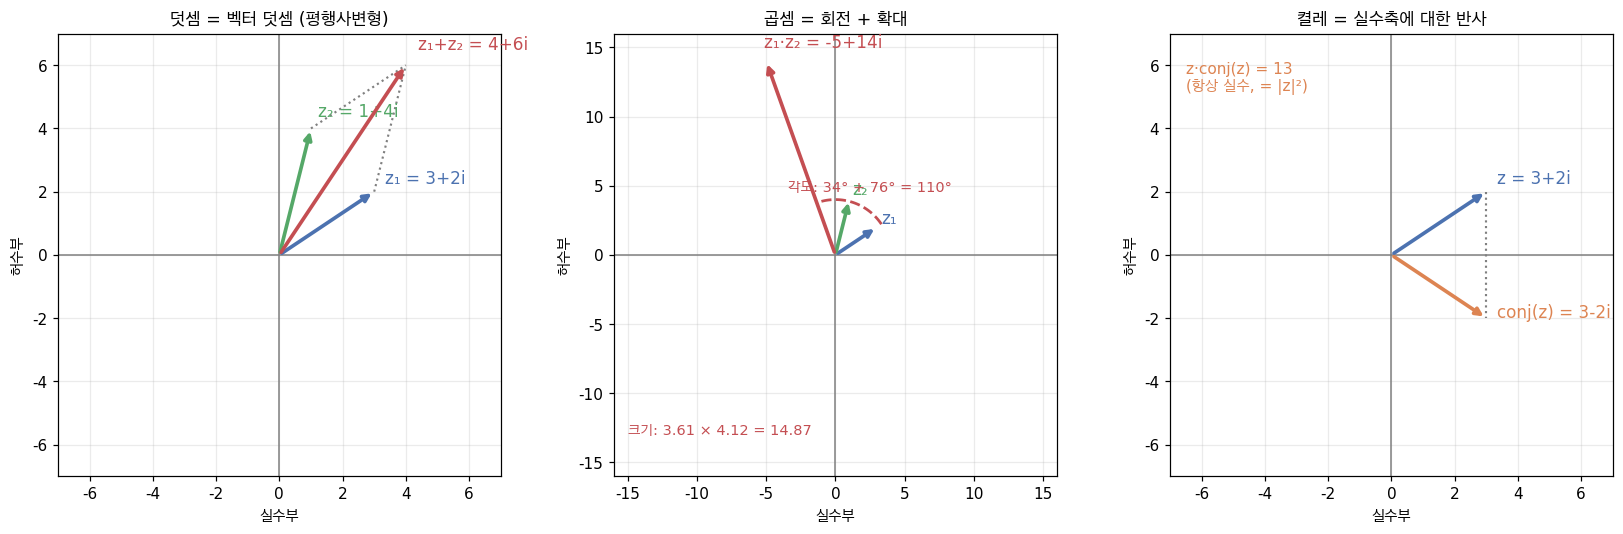

가운데 그림이 이 레슨의 핵심입니다.
  z₁의 각도 33.7° + z₂의 각도 76.0° = 곱의 각도 109.7°
  z₁의 크기 3.6056 × z₂의 크기 4.1231 = 곱의 크기 14.8661

=> 복소수를 곱하면 '각도는 더해지고 크기는 곱해집니다'. 다음 절에서 이걸 정식화합니다.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

def draw_arrow(ax, z, color, label=None, lw=2.4, ls="-"):
    ax.annotate("", xy=(z.real, z.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=lw, color=color, linestyle=ls))
    if label:
        ax.text(z.real * 1.06 + 0.15, z.imag * 1.06 + 0.15, label, fontsize=11, color=color)

def setup(ax, lim=7, title=""):
    ax.axhline(0, color="gray", lw=1); ax.axvline(0, color="gray", lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
    ax.set_xlabel("실수부"); ax.set_ylabel("허수부")
    ax.set_title(title, fontsize=11.5)

a, b = 3 + 2j, 1 + 4j

# (1) 덧셈 = 평행사변형
ax = axes[0]
setup(ax, 7, "덧셈 = 벡터 덧셈 (평행사변형)")
draw_arrow(ax, a, "#4c72b0", "z₁ = 3+2i")
draw_arrow(ax, b, "#55a868", "z₂ = 1+4i")
draw_arrow(ax, a + b, "#c44e52", "z₁+z₂ = 4+6i")
ax.plot([a.real, (a+b).real], [a.imag, (a+b).imag], ls=":", color="gray", lw=1.4)
ax.plot([b.real, (a+b).real], [b.imag, (a+b).imag], ls=":", color="gray", lw=1.4)

# (2) 곱셈 = 회전 + 확대
ax = axes[1]
setup(ax, 16, "곱셈 = 회전 + 확대")
draw_arrow(ax, a, "#4c72b0", "z₁")
draw_arrow(ax, b, "#55a868", "z₂")
draw_arrow(ax, a * b, "#c44e52", "z₁·z₂ = -5+14i")
arc = np.linspace(cmath.phase(a), cmath.phase(a * b), 60)
ax.plot(4 * np.cos(arc), 4 * np.sin(arc), color="#c44e52", lw=1.8, ls="--")
ax.text(-3.4, 4.6, f"각도: {math.degrees(cmath.phase(a)):.0f}° + "
                   f"{math.degrees(cmath.phase(b)):.0f}° = "
                   f"{math.degrees(cmath.phase(a*b)):.0f}°", fontsize=9.5, color="#c44e52")
ax.text(-15, -13, f"크기: {abs(a):.2f} × {abs(b):.2f} = {abs(a*b):.2f}", fontsize=9.5, color="#c44e52")

# (3) 켤레 = 실수축 대칭
ax = axes[2]
setup(ax, 7, "켤레 = 실수축에 대한 반사")
draw_arrow(ax, a, "#4c72b0", "z = 3+2i")
draw_arrow(ax, a.conjugate(), "#dd8452", "conj(z) = 3-2i")
ax.plot([a.real, a.real], [a.imag, -a.imag], ls=":", color="gray", lw=1.4)
ax.text(-6.5, 5.2, f"z·conj(z) = {(a*a.conjugate()).real:.0f}\n(항상 실수, = |z|²)",
        fontsize=10, color="#dd8452")

plt.tight_layout()
plt.show()

print("가운데 그림이 이 레슨의 핵심입니다.")
print(f"  z₁의 각도 {math.degrees(cmath.phase(a)):.1f}° + z₂의 각도 {math.degrees(cmath.phase(b)):.1f}°"
      f" = 곱의 각도 {math.degrees(cmath.phase(a*b)):.1f}°")
print(f"  z₁의 크기 {abs(a):.4f} × z₂의 크기 {abs(b):.4f} = 곱의 크기 {abs(a*b):.4f}")
print("\n=> 복소수를 곱하면 '각도는 더해지고 크기는 곱해집니다'. 다음 절에서 이걸 정식화합니다.")

## 3️⃣ 극형 — 곱셈이 갑자기 쉬워집니다

평면 위의 점은 **원점까지의 거리**와 **양의 실수축에서 잰 각도**로도 나타낼 수 있습니다.

$$z = r(\cos\theta + i\sin\theta), \qquad r = |z| = \sqrt{a^2+b^2}, \quad \theta = \operatorname{atan2}(b, a)$$

- `r` = **크기(magnitude, modulus)**
- `θ` = **위상(phase, argument)**

### 🔑 두 표현의 역할 분담

| | 직교형 `a + bi` | 극형 `(r, θ)` |
| --- | --- | --- |
| **덧셈** | 쉽습니다 (성분끼리 더하기) | 어렵습니다 |
| **곱셈** | 번거롭습니다 (4번 곱하기) | **아주 쉽습니다** |

극형에서 곱셈은 이렇게 됩니다.

$$z_1 z_2 = (r_1 r_2)\, e^{i(\theta_1+\theta_2)}$$

> **크기는 곱하고, 각도는 더합니다.**

2절 그림에서 눈으로 본 게 바로 이겁니다.

### 🔑 그래서 회전이 나옵니다

**크기가 1인 복소수를 곱하면 크기는 그대로고 각도만 바뀝니다. 즉 순수한 회전입니다.**

이게 복소수가 회전에 완벽한 도구인 이유이고, 4절 오일러 공식과 10절 RoPE로 이어집니다.

> ⚠️ **`atan2`를 쓰는 이유:** `atan(b/a)`를 쓰면 2사분면과 4사분면을 구분하지 못합니다.
> `atan2(b, a)`는 두 인자의 부호를 함께 보고 올바른 사분면을 돌려줍니다.
> 아래 코드에서 확인해 보겠습니다.

In [5]:
def to_polar(z):
    return abs(z), cmath.phase(z)

def from_polar(r, theta):
    return r * complex(math.cos(theta), math.sin(theta))

print("직교형 ↔ 극형 변환")
print(f"{'z':>14}{'크기 r':>12}{'각도 θ(도)':>14}{'극형에서 복원':>24}")
print("-" * 66)
for z in [3 + 2j, -1 + 1j, -2 - 2j, 0 + 3j, 1 - 1j]:
    r, th = to_polar(z)
    back = from_polar(r, th)
    print(f"{str(z):>14}{r:>12.4f}{math.degrees(th):>14.2f}{str(np.round(back, 6)):>24}")

print("\n[극형에서 곱셈 = 크기는 곱, 각도는 합]")
z1, z2 = 3 + 2j, 1 + 4j
r1, t1 = to_polar(z1)
r2, t2 = to_polar(z2)
prod_polar = from_polar(r1 * r2, t1 + t2)
print(f"  직교형 곱셈: {z1} × {z2} = {z1*z2}")
print(f"  극형 곱셈  : r={r1:.4f}×{r2:.4f}={r1*r2:.4f},  θ={math.degrees(t1):.2f}°+"
      f"{math.degrees(t2):.2f}°={math.degrees(t1+t2):.2f}°")
print(f"               -> {np.round(prod_polar, 6)}")
print(f"  두 방법의 차이: {abs(z1*z2 - prod_polar):.2e}")

print("\n[⚠️ atan2가 필요한 이유]")
print(f"{'z':>12}{'atan(b/a) 도':>16}{'atan2(b,a) 도':>18}{'올바른 사분면':>16}")
print("-" * 64)
for z in [1 + 1j, -1 - 1j, -1 + 1j, 1 - 1j]:
    naive = math.degrees(math.atan(z.imag / z.real))
    good = math.degrees(math.atan2(z.imag, z.real))
    quad = 1 if (z.real > 0 and z.imag > 0) else 2 if (z.real < 0 and z.imag > 0) \
        else 3 if (z.real < 0 and z.imag < 0) else 4
    print(f"{str(z):>12}{naive:>16.1f}{good:>18.1f}{quad:>16}사분면")
print("  => 1+1i 와 -1-1i 는 정반대 방향인데 atan은 둘 다 45°라고 답합니다.")
print("     atan2는 45°와 -135°로 정확히 구분합니다.")

직교형 ↔ 극형 변환
             z        크기 r       각도 θ(도)                 극형에서 복원
------------------------------------------------------------------
        (3+2j)      3.6056         33.69                  (3+2j)
       (-1+1j)      1.4142        135.00                 (-1+1j)
       (-2-2j)      2.8284       -135.00                 (-2-2j)
            3j      3.0000         90.00                      3j
        (1-1j)      1.4142        -45.00                  (1-1j)

[극형에서 곱셈 = 크기는 곱, 각도는 합]
  직교형 곱셈: (3+2j) × (1+4j) = (-5+14j)
  극형 곱셈  : r=3.6056×4.1231=14.8661,  θ=33.69°+75.96°=109.65°
               -> (-5+14j)
  두 방법의 차이: 2.51e-15

[⚠️ atan2가 필요한 이유]
           z     atan(b/a) 도      atan2(b,a) 도         올바른 사분면
----------------------------------------------------------------
      (1+1j)            45.0              45.0               1사분면
     (-1-1j)            45.0            -135.0               3사분면
     (-1+1j)           -45.0             135.0               2사분면
      (1-1j) 

## 4️⃣ 🔑 오일러 공식 — 이 레슨의 심장

복소지수와 삼각함수를 잇는 다리입니다.

$$\boxed{e^{i\theta} = \cos\theta + i\sin\theta}$$

**이 레슨에서 가장 중요한 한 줄입니다.**

`θ = π`를 넣으면 그 유명한 항등식이 나옵니다.

$$e^{i\pi} = \cos\pi + i\sin\pi = -1 \quad\Longrightarrow\quad e^{i\pi} + 1 = 0$$

다섯 개의 기본 상수(`e`, `i`, `π`, `1`, `0`)가 한 식에 모입니다.

### 🔑 ML을 위해 기억할 진짜 의미

$$|e^{i\theta}| = \sqrt{\cos^2\theta + \sin^2\theta} = 1$$

**크기가 항상 1입니다.** 즉 `e^(iθ)`는 `θ`가 변함에 따라 **단위원을 그립니다.**

| θ | `e^(iθ)` | 위치 |
| --- | --- | --- |
| 0 | 1 | (1, 0) |
| π/2 | i | (0, 1) |
| π | −1 | (−1, 0) |
| 3π/2 | −i | (0, −1) |
| 2π | 1 | 한 바퀴 돌아 제자리 |

> ### **복소지수는 곧 회전입니다.**
> 그리고 회전은 신호처리와 ML 어디에나 있습니다.

### 📐 왜 성립하는가 — 테일러 급수 한 줄

`e^x`, `cos x`, `sin x`의 테일러 급수를 나란히 놓고 `x = iθ`를 대입하면,
**실수 항들이 정확히 `cos`의 급수가 되고 허수 항들이 `sin`의 급수가 됩니다.**
아래에서 직접 확인해 보겠습니다.

In [6]:
def euler(theta):
    return complex(math.cos(theta), math.sin(theta))

print("오일러 공식 검증: e^(iθ) = cos θ + i sin θ\n")
print(f"{'θ':>14}{'내 euler(θ)':>26}{'cmath.exp(iθ)':>26}{'크기':>10}")
print("-" * 78)
for name, th in [("0", 0.0), ("π/4", math.pi/4), ("π/2", math.pi/2),
                 ("π", math.pi), ("3π/2", 3*math.pi/2), ("2π", 2*math.pi)]:
    mine, ref = euler(th), cmath.exp(1j * th)
    print(f"{name:>14}{str(np.round(mine, 6)):>26}{str(np.round(ref, 6)):>26}{abs(mine):>10.4f}")

print(f"\n오일러 항등식: e^(iπ) + 1 = {cmath.exp(1j*math.pi) + 1}")
print(f"  (실수부 {(cmath.exp(1j*math.pi)+1).real:.2e}, 허수부 {(cmath.exp(1j*math.pi)+1).imag:.2e})")
print("  정확히 0이 아닌 건 π가 부동소수점으로 근사되기 때문입니다 (5주차의 그 이야기).")

print("\n[테일러 급수로 확인 — 왜 성립하는가]")
def exp_taylor(z, n_terms=30):
    total, term = 0j, 1 + 0j
    for n in range(n_terms):
        if n > 0:
            term = term * z / n
        total += term
    return total

theta = 1.234
approx = exp_taylor(1j * theta)
print(f"  θ = {theta}")
print(f"  e^(iθ) 를 급수로 계산  : {np.round(approx, 10)}")
print(f"  cos θ + i·sin θ        : {np.round(complex(math.cos(theta), math.sin(theta)), 10)}")
print(f"  차이: {abs(approx - euler(theta)):.2e}")
print("\n  급수의 실수 항들(1 - θ²/2! + θ⁴/4! - ...)이 정확히 cos θ 이고,")
print("  허수 항들(θ - θ³/3! + θ⁵/5! - ...)이 정확히 sin θ 입니다.")
print("  i의 거듭제곱이 1, i, -1, -i 로 순환하면서 항들을 실수/허수로 갈라 놓기 때문입니다.")
print(f"\n  i의 거듭제곱 순환: " + ", ".join(f"i^{k}={np.round(1j**k, 0)}" for k in range(5)))

오일러 공식 검증: e^(iθ) = cos θ + i sin θ

             θ                내 euler(θ)             cmath.exp(iθ)        크기
------------------------------------------------------------------------------
             0                    (1+0j)                    (1+0j)    1.0000
           π/4      (0.707107+0.707107j)      (0.707107+0.707107j)    1.0000
           π/2                        1j                        1j    1.0000
             π                   (-1+0j)                   (-1+0j)    1.0000
          3π/2                   (-0-1j)                   (-0-1j)    1.0000
            2π                    (1-0j)                    (1-0j)    1.0000

오일러 항등식: e^(iπ) + 1 = 1.2246467991473532e-16j
  (실수부 0.00e+00, 허수부 1.22e-16)
  정확히 0이 아닌 건 π가 부동소수점으로 근사되기 때문입니다 (5주차의 그 이야기).

[테일러 급수로 확인 — 왜 성립하는가]
  θ = 1.234
  e^(iθ) 를 급수로 계산  : (0.3304651081+0.9438182094j)
  cos θ + i·sin θ        : (0.3304651081+0.9438182094j)
  차이: 1.11e-16

  급수의 실수 항들(1 - θ²/2! + θ⁴/4! - ...)이 정확히 cos θ 이고,
  허수 항들

## 5️⃣ `i`는 사실 90° 회전 연산자입니다

"허수(imaginary)"라는 이름은 **역사적 사고**입니다. 데카르트가 비하하는 뜻으로 쓴 말이 굳어졌어요.
하지만 `i`는 음수가 처음 등장했을 때만큼도 상상 속 존재가 아닙니다.

- 음수는 **"3에서 5를 빼면?"** 에 답합니다
- 허수 단위는 **"제곱해서 −1이 되는 수는?"** 에 답합니다

### 🔑 더 유용한 해석

> **`i`는 90° 회전 연산자입니다.**

실수에 `i`를 한 번 곱하면 90° 돌아 허수축으로 갑니다.
한 번 더 곱하면(`i²`) 또 90° 돌아 **음의 실수 방향**을 가리킵니다.

**그래서 `i² = −1` 입니다.** 신비로울 게 없어요.
**90° 두 번 = 180° = 방향 뒤집기.** 반 바퀴를 4분의 1 바퀴 두 번으로 만든 것뿐입니다.

```
    1  --×i-->  i  --×i-->  -1  --×i-->  -i  --×i-->  1
   0°          90°        180°         270°        360°
```

이래서 복소수가 공학 전반에 나옵니다.
**회전하는 모든 것** — 전자기파, 양자 상태, 신호 진동, 위치 인코딩 — 이 복소수로 자연스럽게 표현됩니다.

### 🖼️ 그림 2 — `i`를 곱할 때마다 90°씩

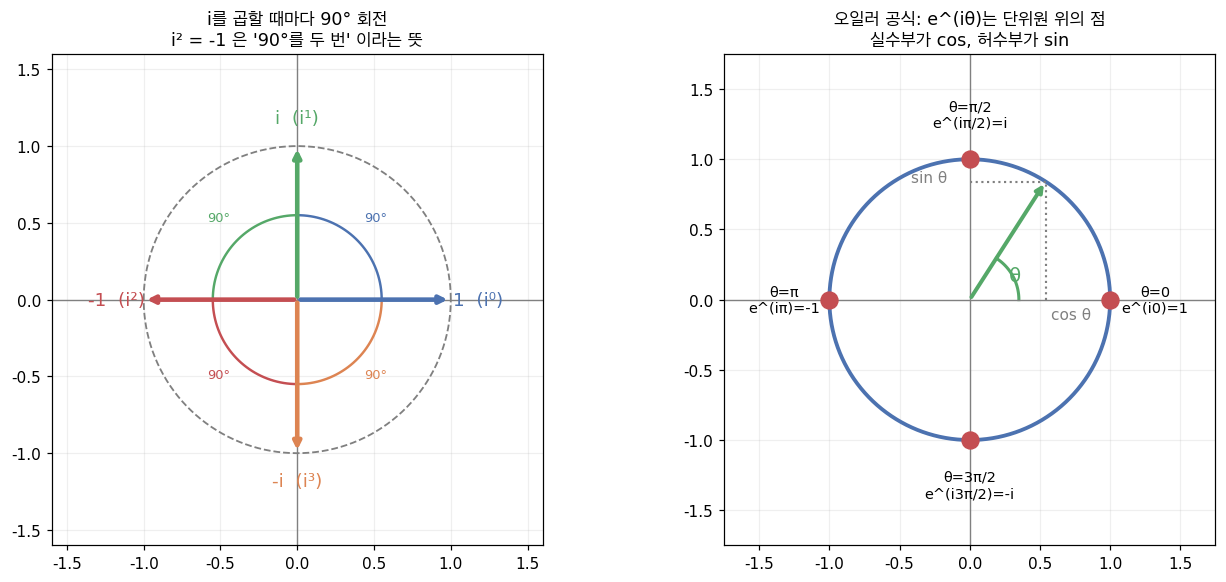

오른쪽 그림에서 점선 두 개를 보세요.
단위원 위의 점을 두 축에 내리면 그게 정확히 cos θ 와 sin θ 입니다.
삼각함수는 사실 '원 위를 도는 운동의 그림자'였던 겁니다. 7절에서 이 관점을 더 씁니다.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.4))

# (1) i의 거듭제곱
th = np.linspace(0, 2*np.pi, 300)
ax1.plot(np.cos(th), np.sin(th), color="gray", lw=1.2, ls="--")
colors = ["#4c72b0", "#55a868", "#c44e52", "#dd8452"]
z = 1 + 0j
for k in range(4):
    ax1.annotate("", xy=(z.real, z.imag), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", lw=3, color=colors[k]))
    lbl = ["1  (i⁰)", "i  (i¹)", "-1  (i²)", "-i  (i³)"][k]
    ax1.text(z.real * 1.18, z.imag * 1.18, lbl, fontsize=12, color=colors[k],
             ha="center", va="center")
    nxt = z * 1j
    arc = np.linspace(cmath.phase(z), cmath.phase(z) + math.pi/2, 40)
    ax1.plot(0.55*np.cos(arc), 0.55*np.sin(arc), color=colors[k], lw=1.6)
    mid = (cmath.phase(z) + math.pi/4)
    ax1.text(0.72*math.cos(mid), 0.72*math.sin(mid), "90°", fontsize=8.5, color=colors[k],
             ha="center")
    z = nxt
ax1.axhline(0, color="gray", lw=0.9); ax1.axvline(0, color="gray", lw=0.9)
ax1.set_xlim(-1.6, 1.6); ax1.set_ylim(-1.6, 1.6); ax1.set_aspect("equal")
ax1.set_title("i를 곱할 때마다 90° 회전\ni² = -1 은 '90°를 두 번' 이라는 뜻", fontsize=11.5)
ax1.grid(alpha=0.2)

# (2) 오일러: e^(iθ)가 단위원을 그린다
ax2.plot(np.cos(th), np.sin(th), color="#4c72b0", lw=2.5)
marks = [(0, "θ=0\ne^(i0)=1"), (math.pi/2, "θ=π/2\ne^(iπ/2)=i"),
         (math.pi, "θ=π\ne^(iπ)=-1"), (3*math.pi/2, "θ=3π/2\ne^(i3π/2)=-i")]
for t, lbl in marks:
    p = euler(t)
    ax2.plot(p.real, p.imag, "o", ms=11, color="#c44e52", zorder=5)
    ax2.text(p.real * 1.32, p.imag * 1.32, lbl, fontsize=9.5, ha="center", va="center")
t_demo = 1.0
p = euler(t_demo)
ax2.annotate("", xy=(p.real, p.imag), xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", lw=2.6, color="#55a868"))
arc = np.linspace(0, t_demo, 40)
ax2.plot(0.35*np.cos(arc), 0.35*np.sin(arc), color="#55a868", lw=2)
ax2.text(0.28, 0.13, "θ", fontsize=13, color="#55a868")
ax2.plot([p.real, p.real], [0, p.imag], ls=":", color="gray", lw=1.4)
ax2.plot([0, p.real], [p.imag, p.imag], ls=":", color="gray", lw=1.4)
ax2.text(p.real + 0.04, -0.14, "cos θ", fontsize=10, color="gray")
ax2.text(-0.42, p.imag, "sin θ", fontsize=10, color="gray")
ax2.axhline(0, color="gray", lw=0.9); ax2.axvline(0, color="gray", lw=0.9)
ax2.set_xlim(-1.75, 1.75); ax2.set_ylim(-1.75, 1.75); ax2.set_aspect("equal")
ax2.set_title("오일러 공식: e^(iθ)는 단위원 위의 점\n실수부가 cos, 허수부가 sin", fontsize=11.5)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()
print("오른쪽 그림에서 점선 두 개를 보세요.")
print("단위원 위의 점을 두 축에 내리면 그게 정확히 cos θ 와 sin θ 입니다.")
print("삼각함수는 사실 '원 위를 도는 운동의 그림자'였던 겁니다. 7절에서 이 관점을 더 씁니다.")

## 6️⃣ 복소수 곱셈 = 2D 회전 행렬 (완전히 같습니다)

`(x + yi)`에 `e^(iθ)`를 곱하면 점 `(x, y)`가 원점을 중심으로 `θ`만큼 회전합니다.
전개해 보면 이렇게 됩니다.

$$(x+yi)(\cos\theta + i\sin\theta) = (x\cos\theta - y\sin\theta) + (x\sin\theta + y\cos\theta)i$$

그런데 3주차에서 배운 **회전 행렬**을 보세요.

$$\begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix}
\begin{bmatrix}x\\y\end{bmatrix} =
\begin{bmatrix}x\cos\theta - y\sin\theta\\ x\sin\theta + y\cos\theta\end{bmatrix}$$

**성분이 정확히 일치합니다.**

> ### 복소수 곱셈은 곧 2D 회전입니다.
> 회전 행렬은 복소수 곱셈을 행렬 기호로 다시 쓴 것에 불과합니다.

### 🔑 그래서 뭐가 좋은가

| | 회전 행렬 | 복소수 |
| --- | --- | --- |
| 저장 | 4개 값 | **2개 값** |
| 두 회전 합성 | 행렬 곱 (곱셈 8회) | **곱셈 하나** |
| 역회전 | 전치 | **켤레** |

10절의 RoPE가 이 효율성을 씁니다. 트랜스포머에서 회전을 수천 번 해야 하는데,
회전 행렬을 만들지 않고 복소수 곱셈(또는 그에 상응하는 sin/cos 페어 연산)으로 처리합니다.

In [8]:
def rotate_complex(x, y, theta):
    return (complex(x, y) * euler(theta))

def rotate_matrix(x, y, theta):
    R = np.array([[math.cos(theta), -math.sin(theta)],
                  [math.sin(theta),  math.cos(theta)]])
    return R @ np.array([x, y])

print("복소수 곱셈 vs 회전 행렬 — 정말 같은가 (연습 5)\n")
rng = np.random.default_rng(0)
max_diff = 0.0
print(f"{'점 (x,y)':>18}{'각도(도)':>12}{'복소수 방식':>26}{'행렬 방식':>26}")
print("-" * 84)
for k in range(5):
    x, y = rng.uniform(-5, 5, 2)
    th = rng.uniform(0, 2 * math.pi)
    zc = rotate_complex(x, y, th)
    vm = rotate_matrix(x, y, th)
    diff = abs(zc - complex(vm[0], vm[1]))
    max_diff = max(max_diff, diff)
    print(f"{f'({x:.2f}, {y:.2f})':>18}{math.degrees(th):>12.1f}"
          f"{f'({zc.real:.5f}, {zc.imag:.5f})':>26}{f'({vm[0]:.5f}, {vm[1]:.5f})':>26}")

# 무작위 1000회로 확대 검증
for _ in range(1000):
    x, y = rng.uniform(-10, 10, 2)
    th = rng.uniform(-4 * math.pi, 4 * math.pi)
    zc = rotate_complex(x, y, th)
    vm = rotate_matrix(x, y, th)
    max_diff = max(max_diff, abs(zc - complex(vm[0], vm[1])))
print(f"\n무작위 1,005회 검증 — 최대 차이: {max_diff:.2e}  (부동소수점 오차 수준) ✓")

print("\n[회전 합성 — 복소수가 훨씬 간단합니다]")
th1, th2 = math.pi / 6, math.pi / 4
p = 2 + 1j
print(f"  점 {p} 를 30° 돌린 뒤 45° 더 돌리기")
step = p * euler(th1) * euler(th2)
once = p * euler(th1 + th2)
print(f"    두 번 곱하기      : {np.round(step, 8)}")
print(f"    각도를 더해 한 번 : {np.round(once, 8)}")
print(f"    차이: {abs(step - once):.2e}")
print("  => 회전 합성이 '각도 덧셈' 하나로 끝납니다. 행렬이면 행렬 곱을 해야 합니다.")

print("\n[역회전 = 켤레]")
rot = euler(th1)
print(f"  30° 회전자      : {np.round(rot, 6)}")
print(f"  그 켤레         : {np.round(rot.conjugate(), 6)}")
print(f"  둘을 곱하면     : {np.round(rot * rot.conjugate(), 10)}   <- 1 (회전 취소)")
print(f"  즉 켤레 = -30° 회전 = {np.round(euler(-th1), 6)}")

복소수 곱셈 vs 회전 행렬 — 정말 같은가 (연습 5)

           점 (x,y)       각도(도)                    복소수 방식                     행렬 방식
------------------------------------------------------------------------------------
     (1.37, -2.30)        14.8       (1.91063, -1.87755)       (1.91063, -1.87755)
     (-4.83, 3.13)       328.6       (-2.49379, 5.19321)       (-2.49379, 5.19321)
      (1.07, 2.29)       195.7      (-0.40534, -2.49794)      (-0.40534, -2.49794)
      (4.35, 3.16)         1.0        (4.29574, 3.23293)        (4.29574, 3.23293)
     (3.57, -4.66)       262.7      (-5.08171, -2.95029)      (-5.08171, -2.95029)

무작위 1,005회 검증 — 최대 차이: 2.51e-15  (부동소수점 오차 수준) ✓

[회전 합성 — 복소수가 훨씬 간단합니다]
  점 (2+1j) 를 30° 돌린 뒤 45° 더 돌리기
    두 번 곱하기      : (-0.44828774+2.1906707j)
    각도를 더해 한 번 : (-0.44828774+2.1906707j)
    차이: 4.97e-16
  => 회전 합성이 '각도 덧셈' 하나로 끝납니다. 행렬이면 행렬 곱을 해야 합니다.

[역회전 = 켤레]
  30° 회전자      : (0.866025+0.5j)
  그 켤레         : (0.866025-0.5j)
  둘을 곱하면     : (1-0j)   <- 1 (회전 취소)
  즉 켤레 = -

## 7️⃣ 페이저 — 사인파는 회전하는 화살표의 그림자

복소지수 `e^(iωt)`는 **각속도 `ω`로 단위원을 도는 점**입니다. `t`가 커지면 점이 원을 그리죠.

$$e^{i\omega t} = \cos(\omega t) + i\sin(\omega t)$$

- **실수부** = `cos(ωt)` — 코사인파
- **허수부** = `sin(ωt)` — 사인파

> **사인파는 회전하는 복소수의 그림자입니다.**

이게 **페이저(phasor)** 표현입니다. 구불구불한 사인파를 쫓아다니는 대신,
**매끄럽게 도는 화살표 하나**를 추적하는 거예요.

| 신호에서의 개념 | 페이저에서는 |
| --- | --- |
| 위상 이동 | 각도 오프셋 |
| 진폭 변화 | 크기 변화 |
| 신호의 덧셈 | **벡터 덧셈** |

### 🔑 왜 공학 전체가 이 표기법으로 갈아탔나

오일러 공식 이전에는 신호를 `A·cos(ωt + φ)`로 썼습니다. 되긴 하는데 계산이 괴롭습니다.
**위상이 다른 두 코사인을 더하려면 삼각함수 항등식을 동원**해야 하거든요.

복소지수로 쓰면 같은 신호가 `A·e^(i(ωt+φ))`입니다.
- 두 신호 더하기 = **복소수 두 개 더하기**
- 변조(곱하기) = **크기 곱하고 각도 더하기**
- 위상 이동 = **각도 덧셈**

**진짜 신호는 항상 복소 표현의 실수부**이고, 허수부는 계산을 매끄럽게 해 주는 장부 역할을 합니다.

In [9]:
# 위상이 다른 두 코사인의 합 — 삼각함수 vs 페이저
A1, phi1 = 3.0, math.radians(30)
A2, phi2 = 2.0, math.radians(120)
omega = 2 * math.pi * 2          # 2 Hz

t = np.linspace(0, 1, 1000)
sig1 = A1 * np.cos(omega * t + phi1)
sig2 = A2 * np.cos(omega * t + phi2)
sig_sum = sig1 + sig2

# 페이저 방식: 복소수 두 개를 더하면 끝
ph1 = A1 * euler(phi1)
ph2 = A2 * euler(phi2)
ph_sum = ph1 + ph2
A_sum, phi_sum = abs(ph_sum), cmath.phase(ph_sum)

print("위상이 다른 두 코사인 더하기\n")
print(f"  신호 1: {A1}·cos(ωt + {math.degrees(phi1):.0f}°)")
print(f"  신호 2: {A2}·cos(ωt + {math.degrees(phi2):.0f}°)")
print(f"\n  페이저로 풀면 — 복소수 덧셈 한 번:")
print(f"    {np.round(ph1, 4)} + {np.round(ph2, 4)} = {np.round(ph_sum, 4)}")
print(f"    -> 합성 진폭 A = {A_sum:.6f},  위상 φ = {math.degrees(phi_sum):.4f}°")

pred = A_sum * np.cos(omega * t + phi_sum)
print(f"\n  검증: 페이저 예측과 실제 파형 합의 최대 차이 = {np.abs(pred - sig_sum).max():.2e} ✓")
print("\n  => 삼각함수 항등식 없이 복소수 덧셈 한 번으로 진폭과 위상을 동시에 얻었습니다.")
print("     이게 공학 전체가 복소 표기법으로 갈아탄 이유입니다.")

위상이 다른 두 코사인 더하기

  신호 1: 3.0·cos(ωt + 30°)
  신호 2: 2.0·cos(ωt + 120°)

  페이저로 풀면 — 복소수 덧셈 한 번:
    (2.5981+1.5j) + (-1+1.7321j) = (1.5981+3.2321j)
    -> 합성 진폭 A = 3.605551,  위상 φ = 63.6901°

  검증: 페이저 예측과 실제 파형 합의 최대 차이 = 4.55e-15 ✓

  => 삼각함수 항등식 없이 복소수 덧셈 한 번으로 진폭과 위상을 동시에 얻었습니다.
     이게 공학 전체가 복소 표기법으로 갈아탄 이유입니다.


### 🖼️ 그림 3 — 회전하는 화살표가 사인파를 그립니다

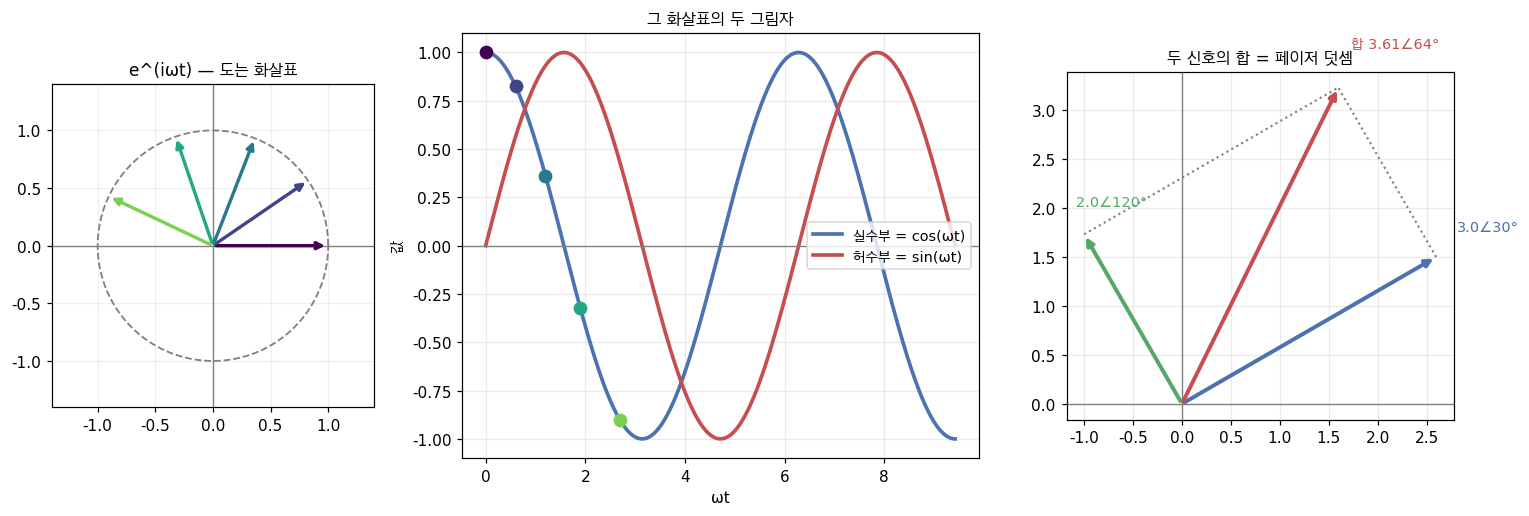

왼쪽 화살표가 돌면서, 가운데 두 파형을 동시에 그려냅니다.
오른쪽은 '위상이 다른 두 신호 더하기'가 그냥 벡터 덧셈이 되는 모습입니다.
삼각함수 항등식이 필요 없어졌습니다.


In [10]:
fig = plt.figure(figsize=(14, 4.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.6, 1.2])

# (1) 회전 원
ax1 = fig.add_subplot(gs[0])
th = np.linspace(0, 2*np.pi, 300)
ax1.plot(np.cos(th), np.sin(th), color="gray", lw=1.2, ls="--")
snapshots = [0, 0.6, 1.2, 1.9, 2.7]
cmap = plt.get_cmap("viridis")
for k, tt in enumerate(snapshots):
    p = euler(tt)
    ax1.annotate("", xy=(p.real, p.imag), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", lw=2.2, color=cmap(k/len(snapshots))))
ax1.axhline(0, color="gray", lw=0.9); ax1.axvline(0, color="gray", lw=0.9)
ax1.set_xlim(-1.4, 1.4); ax1.set_ylim(-1.4, 1.4); ax1.set_aspect("equal")
ax1.set_title("e^(iωt) — 도는 화살표", fontsize=11)
ax1.grid(alpha=0.2)

# (2) 시간에 따른 실수부/허수부
ax2 = fig.add_subplot(gs[1])
tt = np.linspace(0, 3 * np.pi, 600)
ax2.plot(tt, np.cos(tt), lw=2.4, color="#4c72b0", label="실수부 = cos(ωt)")
ax2.plot(tt, np.sin(tt), lw=2.4, color="#c44e52", label="허수부 = sin(ωt)")
for k, s in enumerate(snapshots):
    ax2.plot([s], [math.cos(s)], "o", ms=8, color=cmap(k/len(snapshots)))
ax2.axhline(0, color="gray", lw=0.9)
ax2.set_xlabel("ωt"); ax2.set_ylabel("값")
ax2.set_title("그 화살표의 두 그림자", fontsize=11)
ax2.legend(fontsize=9.5); ax2.grid(alpha=0.25)

# (3) 페이저 덧셈
ax3 = fig.add_subplot(gs[2])
for z, c, lab in [(ph1, "#4c72b0", f"{A1}∠{math.degrees(phi1):.0f}°"),
                  (ph2, "#55a868", f"{A2}∠{math.degrees(phi2):.0f}°"),
                  (ph_sum, "#c44e52", f"합 {A_sum:.2f}∠{math.degrees(phi_sum):.0f}°")]:
    ax3.annotate("", xy=(z.real, z.imag), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", lw=2.6, color=c))
    ax3.text(z.real*1.08, z.imag*1.08 + 0.15, lab, fontsize=9.5, color=c)
ax3.plot([ph1.real, ph_sum.real], [ph1.imag, ph_sum.imag], ls=":", color="gray", lw=1.4)
ax3.plot([ph2.real, ph_sum.real], [ph2.imag, ph_sum.imag], ls=":", color="gray", lw=1.4)
ax3.axhline(0, color="gray", lw=0.9); ax3.axvline(0, color="gray", lw=0.9)
ax3.set_aspect("equal"); ax3.grid(alpha=0.25)
ax3.set_title("두 신호의 합 = 페이저 덧셈", fontsize=11)

plt.tight_layout()
plt.show()

print("왼쪽 화살표가 돌면서, 가운데 두 파형을 동시에 그려냅니다.")
print("오른쪽은 '위상이 다른 두 신호 더하기'가 그냥 벡터 덧셈이 되는 모습입니다.")
print("삼각함수 항등식이 필요 없어졌습니다.")

## 8️⃣ 1의 거듭제곱근

`N`개의 **1의 거듭제곱근(roots of unity)** 은 단위원 위에 **똑같은 간격으로 놓인 `N`개의 점**입니다.

$$\omega_k = e^{2\pi i k/N}, \qquad k = 0, 1, \ldots, N-1$$

- `N = 4` → `1, i, −1, −i` (동서남북 네 방향)
- `N = 8` → 위 네 개 + 대각선 네 개

### 🔑 두 가지 핵심 성질

1. **모든 근의 크기가 정확히 1입니다** → 회전만 하고 크기를 안 바꿉니다
2. **모든 근을 더하면 0입니다** → 대칭이라 서로 상쇄됩니다

이름 그대로 `ωₖ^N = 1`이기도 하고요.

### 🔑 왜 중요한가

**이 성질들이 DFT를 가역적으로 만듭니다.**
1의 거듭제곱근들은 주파수 영역의 **직교 기저**를 이룹니다.

다음 절에서 DFT를 만들 텐데, DFT가 하는 일이 정확히
**"신호가 이 `N`개의 주파수 각각과 얼마나 닮았는지 재는 것"** 입니다.

In [11]:
def roots_of_unity(N):
    return [euler(2 * math.pi * k / N) for k in range(N)]

for N in [4, 8]:
    roots = roots_of_unity(N)
    print(f"[N = {N}] 1의 {N}제곱근")
    for k, w in enumerate(roots):
        print(f"  ω_{k} = {np.round(w, 4)}   크기 {abs(w):.6f}   각도 {math.degrees(cmath.phase(w)):>7.1f}°"
              f"   ω^{N} = {np.round(w**N, 6)}")
    print(f"  모든 근의 합 = {np.round(sum(roots), 12)}   <- 0 ✓")
    print()

print("[성질 검증 — N을 바꿔가며]")
print(f"{'N':>6}{'모든 근의 합 |Σω|':>22}{'모든 크기가 1인가':>20}{'ω_k^N = 1 인가':>18}")
print("-" * 68)
for N in [3, 5, 8, 16, 64, 256]:
    roots = roots_of_unity(N)
    s = abs(sum(roots))
    all_unit = all(abs(abs(w) - 1) < 1e-9 for w in roots)
    all_pow = all(abs(w**N - 1) < 1e-6 for w in roots)
    print(f"{N:>6}{s:>22.2e}{str(all_unit):>20}{str(all_pow):>18}")

print("\n[연습 4] 원시근을 곱하면 다음 근이 나옵니다")
N = 8
roots = roots_of_unity(N)
primitive = roots[1]                       # e^(2πi/8)
print(f"  원시근 ω₁ = {np.round(primitive, 4)}")
ok = True
for k in range(N):
    nxt = roots[k] * primitive
    expected = roots[(k + 1) % N]
    ok &= abs(nxt - expected) < 1e-9
    print(f"    ω_{k} × ω₁ = {np.round(nxt, 4)}   기대값 ω_{(k+1)%N} = {np.round(expected, 4)}")
print(f"  전부 일치? {ok} ✓")
print("\n  => 원시근을 곱하는 것 = 원 위에서 한 칸 옆으로 이동하는 것입니다.")

[N = 4] 1의 4제곱근
  ω_0 = (1+0j)   크기 1.000000   각도     0.0°   ω^4 = (1+0j)
  ω_1 = 1j   크기 1.000000   각도    90.0°   ω^4 = (1-0j)
  ω_2 = (-1+0j)   크기 1.000000   각도   180.0°   ω^4 = (1-0j)
  ω_3 = (-0-1j)   크기 1.000000   각도   -90.0°   ω^4 = (1-0j)
  모든 근의 합 = (-0+0j)   <- 0 ✓

[N = 8] 1의 8제곱근
  ω_0 = (1+0j)   크기 1.000000   각도     0.0°   ω^8 = (1+0j)
  ω_1 = (0.7071+0.7071j)   크기 1.000000   각도    45.0°   ω^8 = (1-0j)
  ω_2 = 1j   크기 1.000000   각도    90.0°   ω^8 = (1-0j)
  ω_3 = (-0.7071+0.7071j)   크기 1.000000   각도   135.0°   ω^8 = (1-0j)
  ω_4 = (-1+0j)   크기 1.000000   각도   180.0°   ω^8 = (1-0j)
  ω_5 = (-0.7071-0.7071j)   크기 1.000000   각도  -135.0°   ω^8 = (1-0j)
  ω_6 = (-0-1j)   크기 1.000000   각도   -90.0°   ω^8 = (1-0j)
  ω_7 = (0.7071-0.7071j)   크기 1.000000   각도   -45.0°   ω^8 = (1-0j)
  모든 근의 합 = (-0-0j)   <- 0 ✓

[성질 검증 — N을 바꿔가며]
     N          모든 근의 합 |Σω|          모든 크기가 1인가      ω_k^N = 1 인가
--------------------------------------------------------------------
     3              

### 🖼️ 그림 4 — 1의 거듭제곱근은 정다각형의 꼭짓점

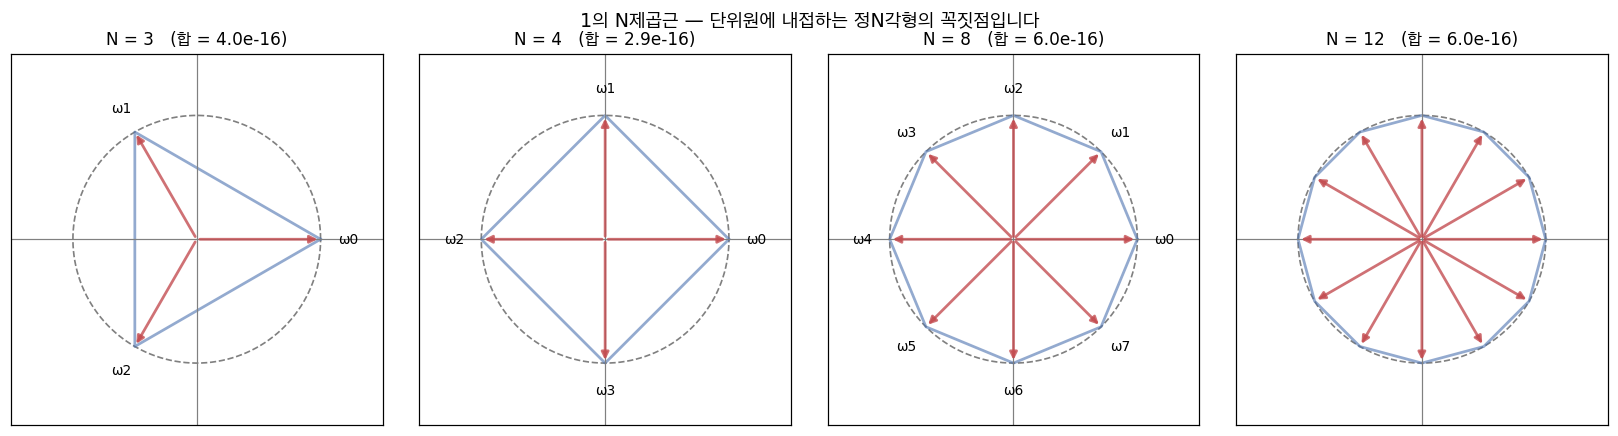

화살표들이 사방으로 고르게 퍼져 있어서, 다 더하면 정확히 0이 됩니다.
이 '고른 퍼짐'이 DFT가 서로 다른 주파수를 깔끔하게 분리할 수 있는 이유입니다.


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
th = np.linspace(0, 2*np.pi, 300)
for ax, N in zip(axes, [3, 4, 8, 12]):
    roots = roots_of_unity(N)
    ax.plot(np.cos(th), np.sin(th), color="gray", lw=1.1, ls="--")
    pts = np.array([[w.real, w.imag] for w in roots])
    poly = np.vstack([pts, pts[:1]])
    ax.plot(poly[:, 0], poly[:, 1], color="#4c72b0", lw=1.8, alpha=0.6)
    for k, w in enumerate(roots):
        ax.annotate("", xy=(w.real, w.imag), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#c44e52", alpha=0.8))
        if N <= 8:
            ax.text(w.real*1.22, w.imag*1.22, f"ω{k}", fontsize=9, ha="center", va="center")
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal")
    ax.set_title(f"N = {N}   (합 = {abs(sum(roots)):.1e})", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("1의 N제곱근 — 단위원에 내접하는 정N각형의 꼭짓점입니다", fontsize=12.5)
plt.tight_layout()
plt.show()
print("화살표들이 사방으로 고르게 퍼져 있어서, 다 더하면 정확히 0이 됩니다.")
print("이 '고른 퍼짐'이 DFT가 서로 다른 주파수를 깔끔하게 분리할 수 있는 이유입니다.")

## 9️⃣ 🔨 DFT와 IDFT를 복소 산술만으로 구현

이제 앞의 조각들을 합칩니다. 신호 `x[0..N−1]`의 **이산 푸리에 변환**은:

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-2\pi i k n/N}$$

지수 부분이 바로 **1의 거듭제곱근**입니다(부호만 음수).

### 🔑 이 식이 하는 일을 말로 풀면

각 `X[k]`는 **"신호가 `k`번째 주파수의 복소 사인파와 얼마나 닮았는가"** 를 재는 값입니다.

- **`|X[k]|`** = 그 주파수 성분의 **진폭**
- **`arg(X[k])`** = 그 성분의 **위상**

즉 DFT는 신호를 **`N`개의 회전하는 페이저로 분해**하고, 각각의 크기와 위상을 알려줍니다.

### 📐 역변환(IDFT)은 부호만 바꾸고 `N`으로 나눕니다

$$x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X[k]\, e^{+2\pi i k n/N}$$

**정보 손실이 전혀 없습니다.** DFT를 하고 IDFT를 하면 원본이 기계 정밀도로 복원됩니다.
아래에서 직접 확인합니다.

> ⚠️ 이 구현은 **O(N²)** 입니다. `N`이 커지면 감당이 안 되죠.
> 다음 노트북에서 이걸 **O(N log N)** 으로 줄이는 **FFT**를 다룹니다.

In [13]:
def dft(signal):
    N = len(signal)
    out = []
    for k in range(N):
        total = 0j
        for n in range(N):
            total += signal[n] * euler(-2 * math.pi * k * n / N)
        out.append(total)
    return out

def idft(spectrum):
    N = len(spectrum)
    out = []
    for n in range(N):
        total = 0j
        for k in range(N):
            total += spectrum[k] * euler(2 * math.pi * k * n / N)
        out.append(total / N)
    return out

# 연습 3: sin(2π·3t) + 0.5·sin(2π·7t) 를 32점 샘플링
N = 32
t = [n / N for n in range(N)]
signal = [math.sin(2*math.pi*3*x) + 0.5*math.sin(2*math.pi*7*x) for x in t]

X = dft(signal)
mag = [abs(v) for v in X]

print(f"신호: sin(2π·3t) + 0.5·sin(2π·7t),  {N}점 샘플링\n")
print(f"{'주파수 k':>10}{'|X[k]|':>14}{'해석':>28}")
print("-" * 54)
for k in range(N // 2 + 1):
    note = ""
    if mag[k] > 1.0:
        note = f"<- 봉우리! 진폭 {2*mag[k]/N:.3f}"
    if mag[k] > 0.5 or k < 9:
        print(f"{k:>10}{mag[k]:>14.4f}{note:>28}")

peak3, peak7 = mag[3], mag[7]
print(f"\n  k=3 봉우리 : {peak3:.4f}")
print(f"  k=7 봉우리 : {peak7:.4f}")
print(f"  비율 k7/k3 : {peak7/peak3:.4f}   <- 기대값 0.5 (원 신호의 진폭 비) ✓")

print("\n[NumPy FFT와 대조]")
np_X = np.fft.fft(np.array(signal))
print(f"  내 DFT와 np.fft.fft의 최대 차이: {np.abs(np.array(X) - np_X).max():.2e} ✓")

print("\n[완전 복원 검증 — DFT → IDFT]")
recovered = idft(X)
err = max(abs(complex(s, 0) - r) for s, r in zip(signal, recovered))
print(f"  원본과 복원본의 최대 차이: {err:.2e}")
print(f"  복원본의 허수부 최대 크기 : {max(abs(r.imag) for r in recovered):.2e}  <- 0 (실수 신호였으니)")
print("  => 정보 손실 없음. DFT는 가역 변환입니다.")

신호: sin(2π·3t) + 0.5·sin(2π·7t),  32점 샘플링

     주파수 k        |X[k]|                          해석
------------------------------------------------------
         0        0.0000                            
         1        0.0000                            
         2        0.0000                            
         3       16.0000            <- 봉우리! 진폭 1.000
         4        0.0000                            
         5        0.0000                            
         6        0.0000                            
         7        8.0000            <- 봉우리! 진폭 0.500
         8        0.0000                            

  k=3 봉우리 : 16.0000
  k=7 봉우리 : 8.0000
  비율 k7/k3 : 0.5000   <- 기대값 0.5 (원 신호의 진폭 비) ✓

[NumPy FFT와 대조]
  내 DFT와 np.fft.fft의 최대 차이: 8.77e-14 ✓

[완전 복원 검증 — DFT → IDFT]
  원본과 복원본의 최대 차이: 1.13e-14
  복원본의 허수부 최대 크기 : 8.41e-15  <- 0 (실수 신호였으니)
  => 정보 손실 없음. DFT는 가역 변환입니다.


### 🖼️ 그림 5 — 신호를 주파수로 분해하기

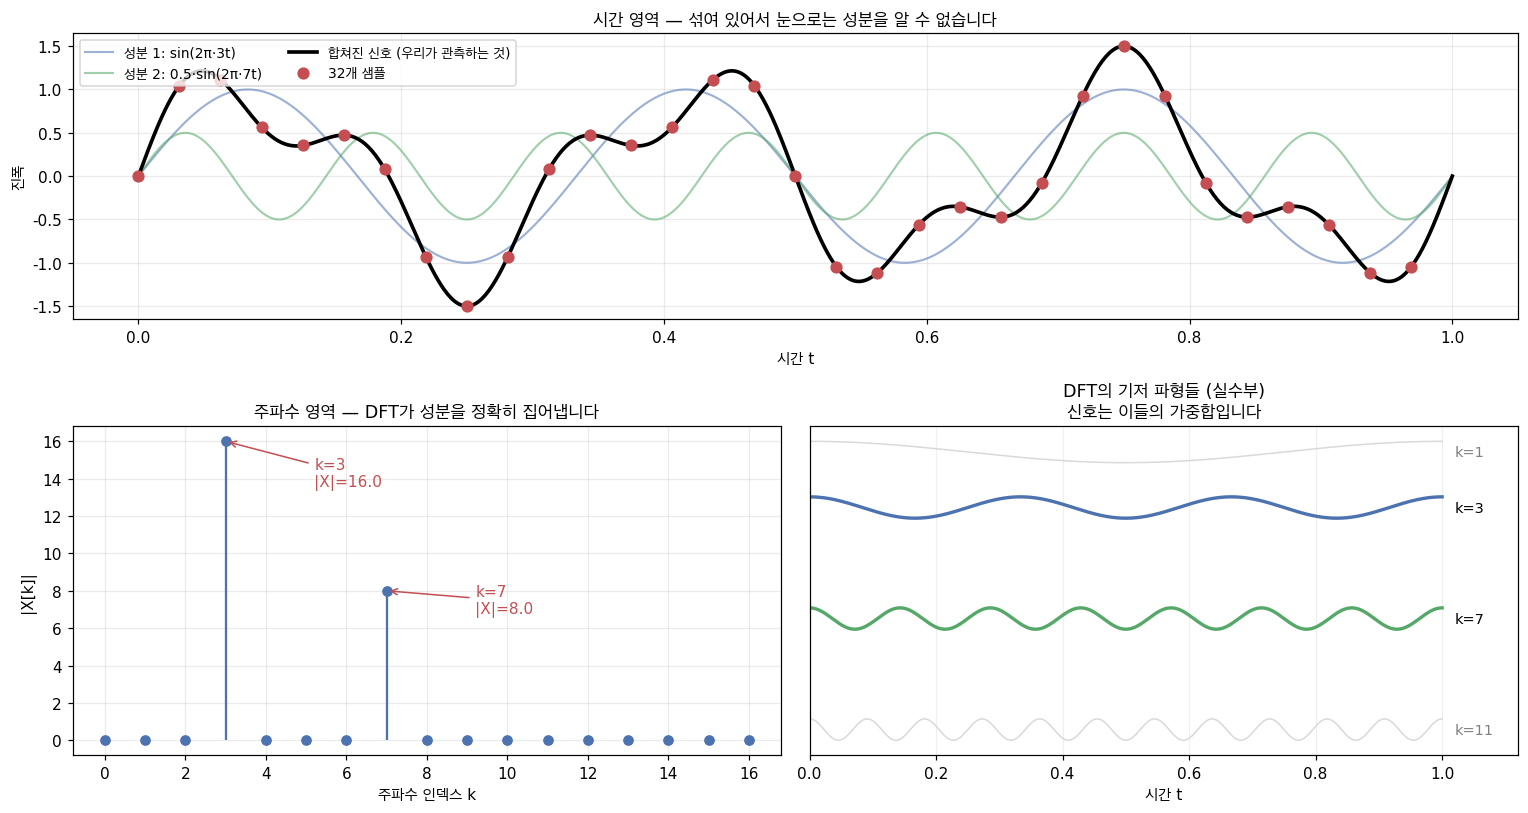

DFT가 하는 일: 위 신호를 오른쪽 아래 기저 파형들의 '가중합'으로 표현하고,
각 가중치의 크기를 왼쪽 아래 막대로 보여 주는 것입니다.
k=3과 k=7에만 큰 값이 있고 나머지는 거의 0입니다 — 원래 그 두 성분만 넣었으니까요.


In [14]:
fig = plt.figure(figsize=(14, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])

# (1) 시간 영역
ax1 = fig.add_subplot(gs[0, :])
t_fine = np.linspace(0, 1, 800)
ax1.plot(t_fine, np.sin(2*np.pi*3*t_fine), lw=1.4, color="#4c72b0", alpha=0.55,
         label="성분 1: sin(2π·3t)")
ax1.plot(t_fine, 0.5*np.sin(2*np.pi*7*t_fine), lw=1.4, color="#55a868", alpha=0.55,
         label="성분 2: 0.5·sin(2π·7t)")
ax1.plot(t_fine, np.sin(2*np.pi*3*t_fine) + 0.5*np.sin(2*np.pi*7*t_fine),
         lw=2.4, color="black", label="합쳐진 신호 (우리가 관측하는 것)")
ax1.plot(t, signal, "o", ms=7, color="#c44e52", zorder=5, label=f"{N}개 샘플")
ax1.set_xlabel("시간 t"); ax1.set_ylabel("진폭")
ax1.set_title("시간 영역 — 섞여 있어서 눈으로는 성분을 알 수 없습니다", fontsize=11.5)
ax1.legend(fontsize=9, ncol=2); ax1.grid(alpha=0.25)

# (2) 크기 스펙트럼
ax2 = fig.add_subplot(gs[1, 0])
ks = np.arange(N)
ax2.stem(ks[:N//2+1], np.array(mag[:N//2+1]), basefmt=" ",
         linefmt="#4c72b0", markerfmt="o")
for k in [3, 7]:
    ax2.annotate(f"k={k}\n|X|={mag[k]:.1f}", xy=(k, mag[k]),
                 xytext=(k + 2.2, mag[k] * 0.85), fontsize=10, color="#c44e52",
                 arrowprops=dict(arrowstyle="->", color="#c44e52"))
ax2.set_xlabel("주파수 인덱스 k"); ax2.set_ylabel("|X[k]|")
ax2.set_title("주파수 영역 — DFT가 성분을 정확히 집어냅니다", fontsize=11.5)
ax2.grid(alpha=0.25)

# (3) 각 주파수의 기저 파형 (1의 거듭제곱근이 만드는 것)
ax3 = fig.add_subplot(gs[1, 1])
for k, color in [(1, "#d9d9d9"), (3, "#4c72b0"), (7, "#55a868"), (11, "#d9d9d9")]:
    basis = [euler(2*math.pi*k*x).real for x in t_fine]
    lw = 2.2 if k in (3, 7) else 1.0
    ax3.plot(t_fine, np.array(basis) - k * 2.6, lw=lw, color=color)
    ax3.text(1.02, -k * 2.6, f"k={k}", fontsize=9.5, va="center",
             color="black" if k in (3, 7) else "gray")
ax3.set_xlim(0, 1.12)
ax3.set_yticks([])
ax3.set_xlabel("시간 t")
ax3.set_title("DFT의 기저 파형들 (실수부)\n신호는 이들의 가중합입니다", fontsize=11.5)
ax3.grid(alpha=0.2, axis="x")

plt.tight_layout()
plt.show()

print("DFT가 하는 일: 위 신호를 오른쪽 아래 기저 파형들의 '가중합'으로 표현하고,")
print("각 가중치의 크기를 왼쪽 아래 막대로 보여 주는 것입니다.")
print(f"k=3과 k=7에만 큰 값이 있고 나머지는 거의 0입니다 — 원래 그 두 성분만 넣었으니까요.")

## 🔟 🏭 트랜스포머 — 사인 위치 인코딩과 RoPE

이제 이 모든 게 왜 ML 커리큘럼에 있는지 밝힐 차례입니다.

### 📐 사인 위치 인코딩 (원조 트랜스포머, 2017)

$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \qquad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

`sin`/`cos` 쌍이 **서로 다른 주파수를 가진 복소지수의 실수부와 허수부**입니다.

$$e^{i \cdot pos \cdot \omega_i} = \cos(pos\cdot\omega_i) + i\sin(pos\cdot\omega_i)$$

각 주파수가 위치를 인코딩하는 **서로 다른 "해상도"** 를 제공합니다.

- **낮은 주파수** → 천천히 변합니다 → **거친 위치** 정보
- **높은 주파수** → 빨리 변합니다 → **세밀한 위치** 정보

이걸 다 합치면 각 위치가 **고유한 주파수 지문**을 갖게 됩니다.
시계의 시침·분침·초침으로 시각을 특정하는 것과 같은 원리예요.

### 📐 RoPE (Rotary Position Embedding) — 한 걸음 더

RoPE는 아예 **쿼리와 키 벡터를 복소 회전으로 직접 곱합니다.**

핵심 아이디어: 위치 `m`의 쿼리를 `e^(imθ)`만큼 회전시키고, 위치 `n`의 키를 `e^(inθ)`만큼 회전시킵니다.
그러면 어텐션 점수(내적)에서 이런 일이 일어납니다.

$$\langle q_m, k_n\rangle = \operatorname{Re}\left[q\,e^{im\theta} \cdot \overline{k\,e^{in\theta}}\right]
= \operatorname{Re}\left[q\bar{k}\,e^{i(m-n)\theta}\right]$$

> ### **절대 위치 `m`, `n`이 사라지고 상대 위치 `m − n`만 남습니다.**

이게 RoPE의 마법입니다. **회전을 두 번 시켰는데 결과는 각도의 차이에만 의존**하게 됩니다.
6절에서 본 "역회전 = 켤레"가 여기서 작동하는 거예요.

아래에서 이 성질을 **직접 코드로 검증**해 보겠습니다.

In [15]:
# 사인 위치 인코딩을 만들어 봅니다
def sinusoidal_pe(max_pos, d_model, base=10000.0):
    pe = np.zeros((max_pos, d_model))
    pos = np.arange(max_pos)[:, None]
    i = np.arange(0, d_model, 2)
    omega = 1.0 / (base ** (i / d_model))
    pe[:, 0::2] = np.sin(pos * omega)
    pe[:, 1::2] = np.cos(pos * omega)
    return pe

PE = sinusoidal_pe(64, 32)
print(f"위치 인코딩 shape: {PE.shape}  (위치 64개 × 차원 32)\n")

print("각 차원 쌍의 주파수 (= 한 바퀴 도는 데 걸리는 위치 수)")
d_model = 32
for i in range(0, 10, 2):
    omega = 1.0 / (10000 ** (i / d_model))
    period = 2 * math.pi / omega
    print(f"  차원 {i},{i+1}: ω = {omega:.6f}   주기 = {period:>12.1f} 위치")
print(f"  ...")
i = 30
omega = 1.0 / (10000 ** (i / d_model))
print(f"  차원 {i},{i+1}: ω = {omega:.6f}   주기 = {2*math.pi/omega:>12.1f} 위치")
print("\n  => 앞쪽 차원은 빨리 돌고(세밀), 뒤쪽 차원은 천천히 돕니다(거칢).")
print("     시계의 초침·분침·시침처럼 여러 해상도를 겹쳐 위치를 특정합니다.")

print("\n[각 위치가 정말 고유한 지문을 갖는가]")
norms = np.linalg.norm(PE, axis=1)
sims = PE @ PE.T / np.outer(norms, norms)
np.fill_diagonal(sims, -np.inf)
print(f"  서로 다른 두 위치의 최대 코사인 유사도: {sims.max():.6f}")
print(f"  (1.0에 가까우면 두 위치를 구분 못 한다는 뜻입니다)")
print(f"  모든 위치 벡터의 노름이 같은가? "
      f"최소 {norms.min():.4f}, 최대 {norms.max():.4f}")

위치 인코딩 shape: (64, 32)  (위치 64개 × 차원 32)

각 차원 쌍의 주파수 (= 한 바퀴 도는 데 걸리는 위치 수)
  차원 0,1: ω = 1.000000   주기 =          6.3 위치
  차원 2,3: ω = 0.562341   주기 =         11.2 위치
  차원 4,5: ω = 0.316228   주기 =         19.9 위치
  차원 6,7: ω = 0.177828   주기 =         35.3 위치
  차원 8,9: ω = 0.100000   주기 =         62.8 위치
  ...
  차원 30,31: ω = 0.000178   주기 =      35332.9 위치

  => 앞쪽 차원은 빨리 돌고(세밀), 뒤쪽 차원은 천천히 돕니다(거칢).
     시계의 초침·분침·시침처럼 여러 해상도를 겹쳐 위치를 특정합니다.

[각 위치가 정말 고유한 지문을 갖는가]
  서로 다른 두 위치의 최대 코사인 유사도: 0.957103
  (1.0에 가까우면 두 위치를 구분 못 한다는 뜻입니다)
  모든 위치 벡터의 노름이 같은가? 최소 4.0000, 최대 4.0000


In [16]:
# 🔑 RoPE — '상대 위치만 남는다'를 직접 검증합니다
def rope_rotate(vec, pos, base=10000.0):
    # 벡터를 2개씩 짝지어 복소수로 보고, 위치에 비례하는 각도만큼 회전시킵니다
    d = len(vec)
    z = vec[0::2] + 1j * vec[1::2]                      # (d/2,) 복소 벡터
    i = np.arange(d // 2)
    theta = 1.0 / (base ** (2 * i / d))
    rotated = z * np.exp(1j * pos * theta)              # e^(i·pos·θ) 곱하기 = 회전
    out = np.empty(d)
    out[0::2] = rotated.real
    out[1::2] = rotated.imag
    return out

rng = np.random.default_rng(7)
d = 64
q = rng.normal(size=d)
k = rng.normal(size=d)

print("RoPE의 핵심 성질: 어텐션 점수가 '상대 위치'에만 의존합니다\n")
print(f"{'q의 위치 m':>12}{'k의 위치 n':>12}{'상대 m-n':>12}{'내적 <q_m, k_n>':>20}")
print("-" * 58)
for m, n in [(5, 3), (10, 8), (50, 48), (100, 98), (7, 2), (20, 15), (99, 94)]:
    score = rope_rotate(q, m) @ rope_rotate(k, n)
    print(f"{m:>12}{n:>12}{m-n:>12}{score:>20.10f}")

print("\n=> 상대 위치가 2인 쌍들(5-3, 10-8, 50-48, 100-98)의 점수가 전부 같습니다.")
print("   상대 위치가 5인 쌍들(7-2, 20-15, 99-94)도 자기들끼리 같고요.")
print("   절대 위치가 5든 100이든 상관없이, 차이만 같으면 어텐션 점수가 같습니다.")

# 수치로 확인
groups = {}
for m in range(0, 60):
    for delta in [1, 3, 7]:
        n = m - delta
        if n < 0:
            continue
        groups.setdefault(delta, []).append(rope_rotate(q, m) @ rope_rotate(k, n))
print(f"\n{'상대 거리':>12}{'표본 수':>10}{'점수 표준편차':>18}{'점수 평균':>16}")
print("-" * 58)
for delta, vals in sorted(groups.items()):
    v = np.array(vals)
    print(f"{delta:>12}{len(v):>10}{v.std():>18.2e}{v.mean():>16.6f}")
print("\n  표준편차가 0에 가깝습니다 = 절대 위치와 무관하다는 뜻입니다 ✓")
print("\n  💡 왜 이렇게 되나: <q·e^(imθ), k·e^(inθ)> = Re[q·conj(k)·e^(i(m-n)θ)]")
print("     6절의 '켤레 = 역회전'이 절대 위치를 상쇄시킵니다.")

RoPE의 핵심 성질: 어텐션 점수가 '상대 위치'에만 의존합니다

     q의 위치 m     k의 위치 n      상대 m-n       내적 <q_m, k_n>
----------------------------------------------------------
           5           3           2        0.9219501073
          10           8           2        0.9219501073
          50          48           2        0.9219501073
         100          98           2        0.9219501073
           7           2           5        1.6152751347
          20          15           5        1.6152751347
          99          94           5        1.6152751347

=> 상대 위치가 2인 쌍들(5-3, 10-8, 50-48, 100-98)의 점수가 전부 같습니다.
   상대 위치가 5인 쌍들(7-2, 20-15, 99-94)도 자기들끼리 같고요.
   절대 위치가 5든 100이든 상관없이, 차이만 같으면 어텐션 점수가 같습니다.

       상대 거리      표본 수           점수 표준편차           점수 평균
----------------------------------------------------------
           1        59          3.59e-15        0.649865
           3        57          2.88e-15        1.249080
           7        53          3.24e-15        2.544689

  표준편차가

### 🖼️ 그림 6 — 위치 인코딩과 RoPE

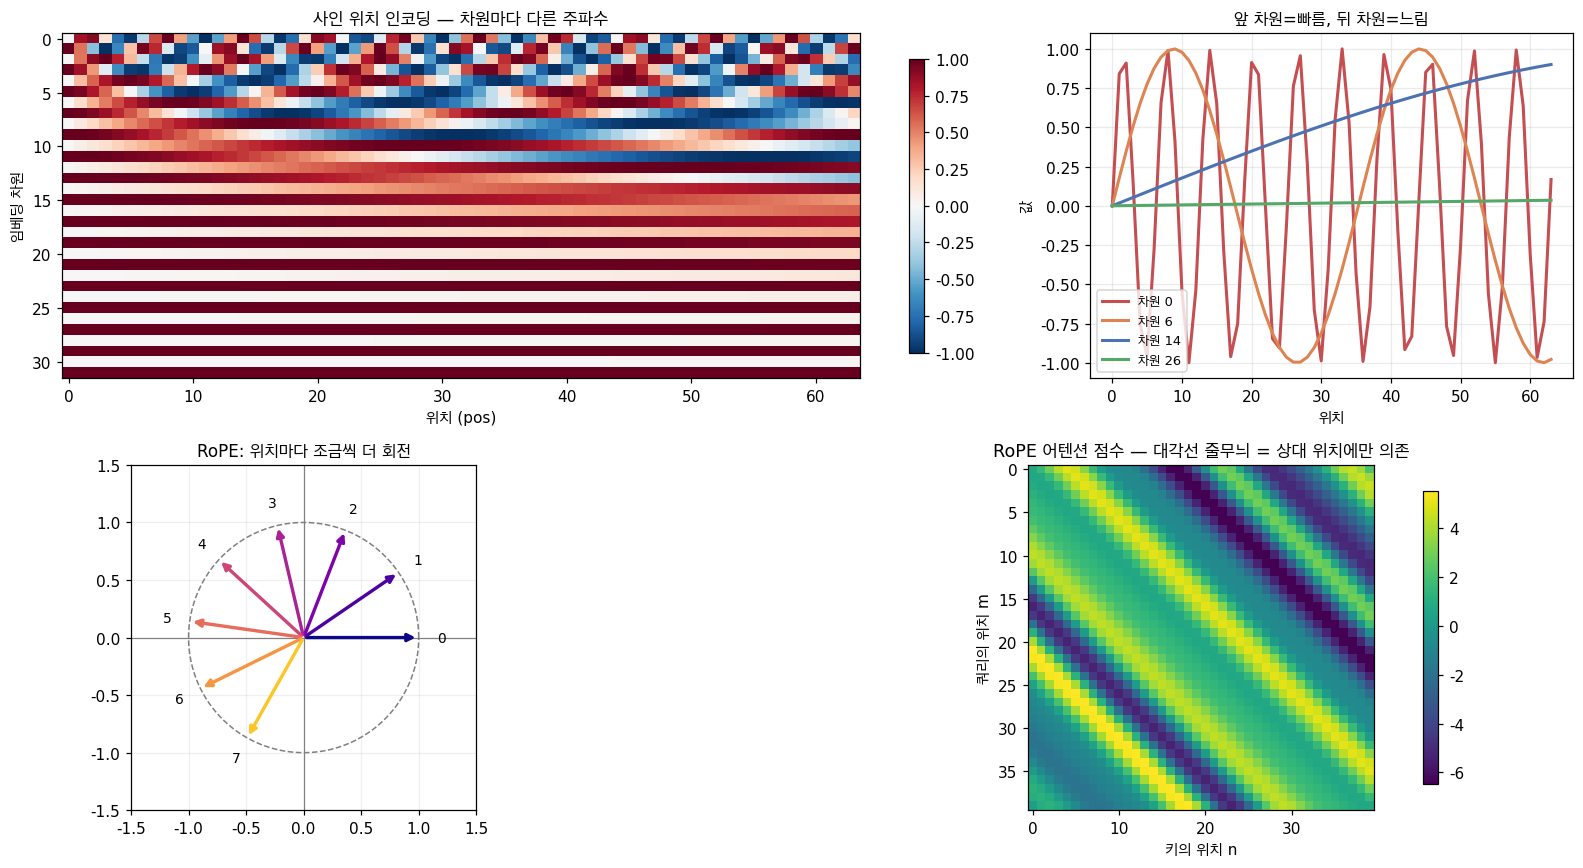

각 대각선(같은 상대 거리) 내부의 표준편차 최댓값: 2.88e-15
오른쪽 아래 그림에서 색이 '대각선 방향으로 일정'합니다.
이게 '절대 위치가 아니라 상대 위치만 본다'는 것의 시각적 증거입니다.


In [17]:
fig = plt.figure(figsize=(14.5, 8))
gs = fig.add_gridspec(2, 3)

# (1) PE 히트맵
ax1 = fig.add_subplot(gs[0, :2])
im = ax1.imshow(PE.T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax1.set_xlabel("위치 (pos)"); ax1.set_ylabel("임베딩 차원")
ax1.set_title("사인 위치 인코딩 — 차원마다 다른 주파수", fontsize=11.5)
plt.colorbar(im, ax=ax1, shrink=0.85)

# (2) 몇 개 차원의 파형
ax2 = fig.add_subplot(gs[0, 2])
for dim, color in [(0, "#c44e52"), (6, "#dd8452"), (14, "#4c72b0"), (26, "#55a868")]:
    ax2.plot(PE[:, dim], lw=2, color=color, label=f"차원 {dim}")
ax2.set_xlabel("위치"); ax2.set_ylabel("값")
ax2.set_title("앞 차원=빠름, 뒤 차원=느림", fontsize=11)
ax2.legend(fontsize=8.5); ax2.grid(alpha=0.25)

# (3) RoPE 회전 시각화
ax3 = fig.add_subplot(gs[1, 0])
th = np.linspace(0, 2*np.pi, 200)
ax3.plot(np.cos(th), np.sin(th), color="gray", lw=1, ls="--")
base_vec = complex(1, 0)
cmap = plt.get_cmap("plasma")
for pos in range(8):
    p = base_vec * np.exp(1j * pos * 0.6)
    ax3.annotate("", xy=(p.real, p.imag), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", lw=2.2, color=cmap(pos/8)))
    ax3.text(p.real*1.2, p.imag*1.2, f"{pos}", fontsize=9, ha="center", va="center")
ax3.set_xlim(-1.5, 1.5); ax3.set_ylim(-1.5, 1.5); ax3.set_aspect("equal")
ax3.axhline(0, color="gray", lw=0.8); ax3.axvline(0, color="gray", lw=0.8)
ax3.set_title("RoPE: 위치마다 조금씩 더 회전", fontsize=11)
ax3.grid(alpha=0.2)

# (4) 어텐션 점수가 상대 위치에만 의존
ax4 = fig.add_subplot(gs[1, 1:])
M = 40
score_mat = np.zeros((M, M))
for m in range(M):
    qm = rope_rotate(q, m)
    for n in range(M):
        score_mat[m, n] = qm @ rope_rotate(k, n)
im2 = ax4.imshow(score_mat, cmap="viridis")
ax4.set_xlabel("키의 위치 n"); ax4.set_ylabel("쿼리의 위치 m")
ax4.set_title("RoPE 어텐션 점수 — 대각선 줄무늬 = 상대 위치에만 의존", fontsize=11.5)
plt.colorbar(im2, ax=ax4, shrink=0.85)

plt.tight_layout()
plt.show()

diag_std = [np.std(np.diagonal(score_mat, offset=o)) for o in range(-M+2, M-1)]
print(f"각 대각선(같은 상대 거리) 내부의 표준편차 최댓값: {max(diag_std):.2e}")
print("오른쪽 아래 그림에서 색이 '대각선 방향으로 일정'합니다.")
print("이게 '절대 위치가 아니라 상대 위치만 본다'는 것의 시각적 증거입니다.")

## 1️⃣1️⃣ 📝 연습문제 (풀이 포함)

1. **손으로 복소 산술** — `(2+3i)(4−i)`와 `(5+2i)/(1−3i)`를 계산하고 코드로 검증. 복소평면에 그려서 곱셈이 회전·확대임을 확인.
2. **회전 시퀀스** — `(1,0)`에서 시작해 `e^(iπ/6)`을 12번 곱하면 제자리로 돌아오는지 확인. 정12각형을 그리는지도.
3. **알려진 신호의 DFT** — `sin(2π·3t) + 0.5·sin(2π·7t)`를 32점 샘플링해 봉우리가 3과 7에, 높이 비가 1:0.5인지 확인. *(→ 9절에서 완료)*
4. **1의 거듭제곱근** — 8제곱근의 합이 0인지, 원시근을 곱하면 다음 근이 나오는지 확인. *(→ 8절에서 완료)*
5. **회전 행렬 동치** — 무작위 각도·점 10쌍에 대해 복소수 곱셈과 회전 행렬이 같은 결과를 주는지 확인. *(→ 6절에서 완료)*

In [18]:
print("=" * 74)
print("연습 1 — 손 계산과 코드 대조")
print("=" * 74)
print("(a) (2+3i)(4-i)")
print("    = 8 - 2i + 12i - 3i²")
print("    = 8 + 10i + 3          (i² = -1 이므로 -3i² = +3)")
print("    = 11 + 10i")
r1 = (2+3j) * (4-1j)
print(f"    코드: {r1}   일치 ✓\n")

print("(b) (5+2i)/(1-3i)  — 분모의 켤레 (1+3i)를 위아래에 곱합니다")
print("    분자: (5+2i)(1+3i) = 5 + 15i + 2i + 6i² = 5 + 17i - 6 = -1 + 17i")
print("    분모: (1-3i)(1+3i) = 1 + 9 = 10")
print("    = (-1 + 17i)/10 = -0.1 + 1.7i")
r2 = (5+2j) / (1-3j)
print(f"    코드: {r2}   일치 ✓")

print(f"\n[곱셈이 회전·확대인지 확인]  (a)의 경우")
z_a, z_b = 2+3j, 4-1j
print(f"  {z_a}: 크기 {abs(z_a):.4f}, 각도 {math.degrees(cmath.phase(z_a)):.2f}°")
print(f"  {z_b}: 크기 {abs(z_b):.4f}, 각도 {math.degrees(cmath.phase(z_b)):.2f}°")
print(f"  곱  {r1}: 크기 {abs(r1):.4f}, 각도 {math.degrees(cmath.phase(r1)):.2f}°")
print(f"  크기 검증: {abs(z_a):.4f} × {abs(z_b):.4f} = {abs(z_a)*abs(z_b):.4f} "
      f"(실제 {abs(r1):.4f}) ✓")
print(f"  각도 검증: {math.degrees(cmath.phase(z_a)):.2f}° + {math.degrees(cmath.phase(z_b)):.2f}° = "
      f"{math.degrees(cmath.phase(z_a)+cmath.phase(z_b)):.2f}° (실제 {math.degrees(cmath.phase(r1)):.2f}°) ✓")

연습 1 — 손 계산과 코드 대조
(a) (2+3i)(4-i)
    = 8 - 2i + 12i - 3i²
    = 8 + 10i + 3          (i² = -1 이므로 -3i² = +3)
    = 11 + 10i
    코드: (11+10j)   일치 ✓

(b) (5+2i)/(1-3i)  — 분모의 켤레 (1+3i)를 위아래에 곱합니다
    분자: (5+2i)(1+3i) = 5 + 15i + 2i + 6i² = 5 + 17i - 6 = -1 + 17i
    분모: (1-3i)(1+3i) = 1 + 9 = 10
    = (-1 + 17i)/10 = -0.1 + 1.7i
    코드: (-0.10000000000000002+1.7j)   일치 ✓

[곱셈이 회전·확대인지 확인]  (a)의 경우
  (2+3j): 크기 3.6056, 각도 56.31°
  (4-1j): 크기 4.1231, 각도 -14.04°
  곱  (11+10j): 크기 14.8661, 각도 42.27°
  크기 검증: 3.6056 × 4.1231 = 14.8661 (실제 14.8661) ✓
  각도 검증: 56.31° + -14.04° = 42.27° (실제 42.27°) ✓


In [19]:
print("=" * 74)
print("연습 2 — 회전 시퀀스 (정12각형)")
print("=" * 74)
z = 1 + 0j
rot = euler(math.pi / 6)                     # 30°
print(f"회전자 e^(iπ/6) = {np.round(rot, 6)}  (30°)\n")
print(f"{'단계':>6}{'좌표':>28}{'각도(도)':>12}{'크기':>10}")
print("-" * 58)
pts = [z]
for k in range(12):
    z = z * rot
    pts.append(z)
    print(f"{k+1:>6}{f'({z.real:>9.6f}, {z.imag:>9.6f})':>28}"
          f"{math.degrees(cmath.phase(z)) % 360:>12.2f}{abs(z):>10.6f}")

print(f"\n12번 곱한 뒤 (1,0)으로 돌아왔는가?  차이 = {abs(pts[-1] - (1+0j)):.2e} ✓")
print(f"모든 점의 크기가 1인가?  최대 편차 = {max(abs(abs(p)-1) for p in pts):.2e} ✓")

# 정12각형인지: 이웃한 점 사이 거리가 모두 같은가
dists = [abs(pts[i+1] - pts[i]) for i in range(12)]
print(f"이웃 점 사이 거리가 모두 같은가? 최소 {min(dists):.6f}, 최대 {max(dists):.6f}")
print(f"  이론값 2·sin(π/12) = {2*math.sin(math.pi/12):.6f} ✓  -> 정12각형입니다")

연습 2 — 회전 시퀀스 (정12각형)
회전자 e^(iπ/6) = (0.866025+0.5j)  (30°)

    단계                          좌표       각도(도)        크기
----------------------------------------------------------
     1      ( 0.866025,  0.500000)       30.00  1.000000
     2      ( 0.500000,  0.866025)       60.00  1.000000
     3      ( 0.000000,  1.000000)       90.00  1.000000
     4      (-0.500000,  0.866025)      120.00  1.000000
     5      (-0.866025,  0.500000)      150.00  1.000000
     6      (-1.000000,  0.000000)      180.00  1.000000
     7      (-0.866025, -0.500000)      210.00  1.000000
     8      (-0.500000, -0.866025)      240.00  1.000000
     9      (-0.000000, -1.000000)      270.00  1.000000
    10      ( 0.500000, -0.866025)      300.00  1.000000
    11      ( 0.866025, -0.500000)      330.00  1.000000
    12      ( 1.000000, -0.000000)      360.00  1.000000

12번 곱한 뒤 (1,0)으로 돌아왔는가?  차이 = 9.36e-16 ✓
모든 점의 크기가 1인가?  최대 편차 = 0.00e+00 ✓
이웃 점 사이 거리가 모두 같은가? 최소 0.517638, 최대 0.517638
  이론값 2·sin(π/12)

### 🖼️ 그림 7 — 연습 2의 정12각형

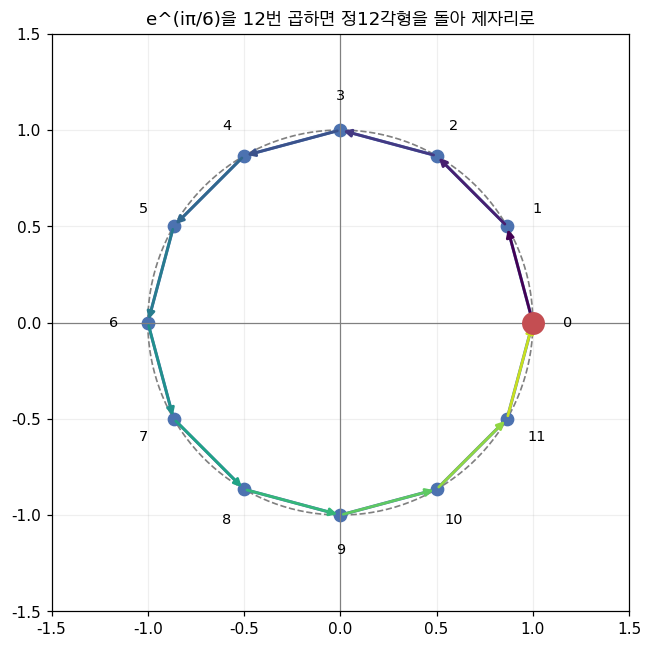

30° × 12 = 360°. 정확히 한 바퀴입니다.
그리고 이 12개 점이 바로 '1의 12제곱근'이기도 합니다 (8절).


In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
th = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(th), np.sin(th), color="gray", lw=1.1, ls="--")
arr = np.array([[p.real, p.imag] for p in pts])
ax.plot(arr[:, 0], arr[:, 1], "-o", lw=2, ms=8, color="#4c72b0")
cmap = plt.get_cmap("viridis")
for k in range(12):
    ax.annotate("", xy=arr[k+1], xytext=arr[k],
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color=cmap(k/12)))
    ax.text(arr[k, 0]*1.18, arr[k, 1]*1.18, f"{k}", fontsize=9.5, ha="center", va="center")
ax.plot(1, 0, "o", ms=14, color="#c44e52", zorder=6)
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal")
ax.set_title("e^(iπ/6)을 12번 곱하면 정12각형을 돌아 제자리로", fontsize=12)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("30° × 12 = 360°. 정확히 한 바퀴입니다.")
print("그리고 이 12개 점이 바로 '1의 12제곱근'이기도 합니다 (8절).")

## 1️⃣2️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 실제 의미 |
| --- | --- |
| **복소수** | `a + bi` 꼴의 수. `a`는 실수부, `b`는 허수부, `i² = −1` |
| **허수 단위 `i`** | `i² = −1`로 정의되는 수. 철학적 의미의 "상상"이 아니라 **90° 회전 연산자** |
| **복소평면** | 가로축이 실수, 세로축이 허수인 2D 평면. 아르강 평면이라고도 합니다 |
| **크기(modulus)** | 원점까지의 거리 `√(a²+b²)`. `\|z\|`로 씁니다 |
| **위상(argument)** | 양의 실수축에서 잰 각도 `atan2(b, a)`. `arg(z)`로 씁니다 |
| **켤레(conjugate)** | 실수축에 대한 거울상. `a + bi` → `a − bi`. **역회전에 해당합니다** |
| **극형** | `z`를 `a + bi` 대신 `r·e^(iθ)`로 쓰기. 곱셈이 쉬워집니다 |
| **오일러 공식** | `e^(iθ) = cos θ + i sin θ`. 지수와 삼각함수를 잇습니다 |
| **페이저** | 사인 신호를 나타내는 회전 복소수 `e^(iωt)` |
| **1의 거듭제곱근** | `e^(2πik/N)`, `k=0..N−1`. 단위원 위에 고르게 놓인 `N`개의 점 |
| **DFT** | 이산 푸리에 변환. 1의 거듭제곱근을 이용해 신호를 주파수 성분으로 분해 |
| **RoPE** | Rotary Position Embedding. **복소 회전으로 상대 위치를 인코딩**하는 트랜스포머 기법 |

---

## 🎯 한 문장 정리

> **`i`를 곱하는 것은 90° 회전이고, `e^(iθ)`를 곱하는 것은 `θ` 회전입니다.
> 이 한 줄에서 오일러 공식, 페이저, 거듭제곱근, DFT, RoPE가 전부 따라 나옵니다.**

| 개념 | 회전으로 보면 |
| --- | --- |
| `i² = −1` | 90°를 두 번 = 180° |
| 오일러 공식 | 단위원 위를 도는 점의 좌표 |
| 곱셈 | 각도는 더하고, 크기는 곱하기 |
| 켤레 | 반대 방향 회전 |
| 페이저 | 도는 화살표의 그림자가 사인파 |
| 1의 거듭제곱근 | 원을 `N`등분한 점들 |
| DFT | 신호를 `N`개의 회전 성분으로 분해 |
| **RoPE** | **회전 두 번의 차이 = 상대 위치** |

다음 노트북에서는 이 DFT를 **O(N log N)** 으로 가속하는 **FFT**를 만듭니다.

---

## 📖 더 읽을거리

- [Visual Introduction to Euler's Formula](https://betterexplained.com/articles/intuitive-understanding-of-eulers-formula/) — 무거운 기호 없이 기하학적 직관을 세워 줍니다
- [Su et al.: RoFormer (2021)](https://arxiv.org/abs/2104.09864) — RoPE를 도입한 논문
- [Vaswani et al.: Attention Is All You Need (2017)](https://arxiv.org/abs/1706.03762) — 사인 위치 인코딩의 원조
- [3Blue1Brown: 오일러 공식과 군론](https://www.youtube.com/watch?v=mvmuCPvRoWQ) — `e^(iπ) = −1`의 시각적 설명
- [Needham: Visual Complex Analysis](https://global.oup.com/academic/product/visual-complex-analysis-9780198534464) — 복소수를 기하학으로 다루는 최고의 책